In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tensorflow.keras.layers import BatchNormalization
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import imagehash
from tqdm import tqdm
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")


2025-12-03 19:39:51.787677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764790791.986626      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764790792.042815      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:

def load_image_paths(data_path):
    data = []
    classes = sorted(os.listdir(data_path))

    for cls in classes:
        folder = os.path.join(data_path, cls)
        if not os.path.isdir(folder):
            continue
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            data.append({"path": img_path, "class_name": cls})
    
    return pd.DataFrame(data)

# Paths
train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_path  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

# Load separately
train_df = load_image_paths(train_path)
test_df  = load_image_paths(test_path)

# Merge
full_df = pd.concat([train_df, test_df], ignore_index=True)

print("Before removing duplicates:", full_df.shape)


Before removing duplicates: (7023, 2)


In [6]:
full_df.columns


Index(['path', 'class_name'], dtype='object')

In [8]:
import os
from PIL import Image

missing_files = []
corrupted_files = []
empty_folders = []

# Convert path column to list
all_paths = full_df["path"].tolist()

# Extract the root directory of all images
root_dir = os.path.commonpath(all_paths)

# 1️⃣ Check empty folders
for root, dirs, files in os.walk(root_dir):
    if len(files) == 0:
        empty_folders.append(root)

# 2️⃣ Check each image in the DataFrame
for file_path in all_paths:
    # File missing (path does not exist)
    if not os.path.exists(file_path):
        missing_files.append(file_path)
        continue
    
    # File size = 0 bytes
    if os.path.getsize(file_path) == 0:
        missing_files.append(file_path)
        continue
    
    # Check if corrupted
    try:
        with Image.open(file_path) as img:
            img.verify()
    except Exception:
        corrupted_files.append(file_path)

# Print results
print("\n📂 Image check completed ✅")
print(f"🔸 Missing images (not found or size=0): {len(missing_files)}")
print(f"🔸 Corrupted images: {len(corrupted_files)}")
print(f"🔸 Empty folders: {len(empty_folders)}")

if missing_files:
    print("\n🧾 Example missing images:")
    print("\n".join(missing_files[:5]))

if corrupted_files:
    print("\n🧾 Example corrupted images:")
    print("\n".join(corrupted_files[:5]))

if empty_folders:
    print("\n📁 Empty folders:")
    print("\n".join(empty_folders[:5]))



📂 Image check completed ✅
🔸 Missing images (not found or size=0): 0
🔸 Corrupted images: 0
🔸 Empty folders: 3

📁 Empty folders:
/kaggle/input/brain-tumor-mri-dataset
/kaggle/input/brain-tumor-mri-dataset/Training
/kaggle/input/brain-tumor-mri-dataset/Testing


In [9]:

import tensorflow as tf
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

# Load model for deep features
model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    pooling="avg",
    weights="imagenet"
)

def extract_features(path):
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize((224, 224))
        arr = np.array(img)
        arr = tf.keras.applications.efficientnet.preprocess_input(arr)
        arr = np.expand_dims(arr, 0)

        features = model.predict(arr, verbose=0)[0]
        return features
    except:
        return None

# Extract features
tqdm.pandas()
full_df["features"] = full_df["path"].progress_apply(extract_features)

# Remove errors
full_df = full_df.dropna(subset=["features"])

# Convert features to tuple for hashing duplicates
full_df["features_tuple"] = full_df["features"].apply(lambda x: tuple(np.round(x, 3)))

# Remove duplicates
full_df = full_df.drop_duplicates(subset=["features_tuple"], keep="first")

full_df = full_df.drop(columns=["features_tuple"])
print("Remaining:", full_df.shape)

# def compute_phash(image_path):
#     try:
#         img = Image.open(image_path)
#         img = img.convert("L").resize((128, 128))
#         return str(imagehash.phash(img))
#     except:
#         return None

# # Compute pHash for all images
# tqdm.pandas()
# full_df["phash"] = full_df["path"].progress_apply(compute_phash)

# # Remove corrupted images (no hash)
# full_df = full_df.dropna(subset=["phash"])

# # Remove duplicates
# full_df = full_df.drop_duplicates(subset=["phash"], keep="first")

# print("After removing duplicates:", full_df.shape)


I0000 00:00:1764791350.033174      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


  0%|          | 0/7023 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1764791356.476566     125 service.cc:148] XLA service 0x7d9260046da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764791356.477077     125 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764791357.167415     125 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764791361.011180     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 7023/7023 [08:36<00:00, 13.60it/s]


Remaining: (6597, 3)


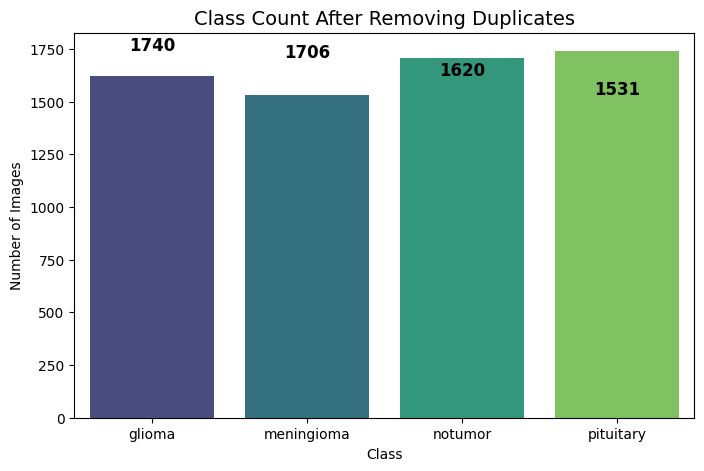

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=full_df, x="class_name", palette="viridis")

plt.title("Class Count After Removing Duplicates", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, c in enumerate(full_df["class_name"].value_counts().values):
    plt.text(i, c+3, str(c), ha="center", fontsize=12, fontweight="bold")

plt.show()


In [11]:
from sklearn.model_selection import train_test_split

# 70% train + 30% temp
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.30,
    random_state=42,
    stratify=full_df["class_name"]
)

# Split temp into 15% val + 15% test
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_name"]
)

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)


Train: (4617, 3)
Validation: (990, 3)
Test: (990, 3)


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (299, 299)
BATCH_SIZE = 32

# 🔹 Train generator with brightness augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    brightness_range=(0.8, 1.25),
    fill_mode='nearest'
)

# 🔹 Validation & test generators (no augmentation)
test_valid_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='class_name',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Validation generator
valid_data = test_valid_datagen.flow_from_dataframe(
    valid_df,
    x_col='path',
    y_col='class_name',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test generator
test_data = test_valid_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='class_name',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 4617 validated image filenames belonging to 4 classes.
Found 990 validated image filenames belonging to 4 classes.
Found 990 validated image filenames belonging to 4 classes.


In [16]:
img_shape = (299, 299, 3)
weights_path = "/kaggle/input/xception/xception_weights_tf_dim_ordering_tf_kernels_notop.h5"
# Load the base Xception model
base_model = tf.keras.applications.Xception(
    include_top=False,
    weights=weights_path,
    input_shape=img_shape,
    pooling='max'
)
# Freeze the base layers (prevent training them)
# base_model.trainable = False
# Build the final model
model = Sequential([
    base_model,
    # Flatten(),
    BatchNormalization(),
    Dropout(rate=0.3),
    Dense(128, activation='relu'),
    Dropout(rate=0.25),
    Dense(4, activation='softmax')
])
# Set up the training
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)
# model.summary()

In [17]:
from tensorflow.keras.callbacks import EarlyStopping  

# Create EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',          # Monitor validation loss (best for generalization)
    patience=7,                  # Wait 7 epochs with no improvement before stopping
    verbose=1,                   # Print a message when training stops
    mode='min',                  # Minimize the loss
    restore_best_weights=True    # Restore model weights from the best epoch
)

# Train the model
hist = model.fit(
    train_data,
    epochs=20,                   # You can increase to 20+; it will stop early automatically
    validation_data=valid_data,
    callbacks=[early_stop]       # Add the EarlyStopping callback here
    # shuffle=False  # optional
)

# Extract training history
history = hist.history

# # Print final results (with corrected metric names)
# print("\nFinal Training Results:")
# print(f"Training Accuracy: {history['accuracy'][-1]:.4f}")
# print(f"Validation Accuracy: {history['val_accuracy'][-1]:.4f}")
# print(f"Training Loss: {history['loss'][-1]:.4f}")
# print(f"Validation Loss: {history['val_loss'][-1]:.4f}")
# print(f"Training Precision: {history['precision'][-1]:.4f}")
# print(f"Validation Precision: {history['val_precision'][-1]:.4f}")
# print(f"Training Recall: {history['recall'][-1]:.4f}")
# print(f"Validation Recall: {history['val_recall'][-1]:.4f}")


Epoch 1/20


E0000 00:00:1764792142.722654     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792142.961682     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792144.306791     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792144.548158     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792146.149615     126 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

107/145 ━━━━━━━━━━━━━━━━━━━━ 29s 769ms/step - accuracy: 0.7874 - loss: 0.6774 - precision: 0.7998 - recall: 0.7759

E0000 00:00:1764792248.155744     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792248.352680     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792249.266072     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792249.492015     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792249.717739     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.8133 - loss: 0.5998 - precision: 0.8243 - recall: 0.8029

E0000 00:00:1764792299.171016     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792299.414616     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792300.080472     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792300.346482     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764792300.618525     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-03

145/145 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8139 - loss: 0.5981 - precision: 0.8248 - recall: 0.8035 - val_accuracy: 0.8626 - val_loss: 0.5142 - val_precision: 0.8644 - val_recall: 0.8626
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 118s 809ms/step - accuracy: 0.9672 - loss: 0.0971 - precision: 0.9692 - recall: 0.9650 - val_accuracy: 0.9697 - val_loss: 0.1190 - val_precision: 0.9706 - val_recall: 0.9657
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 116s 799ms/step - accuracy: 0.9780 - loss: 0.0593 - precision: 0.9794 - recall: 0.9770 - val_accuracy: 0.9687 - val_loss: 0.1154 - val_precision: 0.9687 - val_recall: 0.9687
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 119s 816ms/step - accuracy: 0.9857 - loss: 0.0364 - precision: 0.9863 - recall: 0.9855 - val_accuracy: 0.9697 - val_loss: 0.1581 - val_precision: 0.9697 - val_recall: 0.9697
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 118s 811ms/step - accuracy: 0.9950 - loss: 0.0186 - precision: 0.9950 - recall: 0.9949 - val_accuracy: 0.9626 - val_lo

In [18]:
train_score = model.evaluate(train_data, verbose=1)
valid_score = model.evaluate(valid_data, verbose=1)
test_score = model.evaluate(test_data, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

145/145 ━━━━━━━━━━━━━━━━━━━━ 100s 686ms/step - accuracy: 0.9996 - loss: 0.0013 - precision: 0.9996 - recall: 0.9996
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9913 - loss: 0.0490 - precision: 0.9913 - recall: 0.9913
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9924 - loss: 0.0720 - precision: 0.9924 - recall: 0.9924
Train Loss: 0.0011
Train Accuracy: 99.96%
--------------------
Validation Loss: 0.0491
Validation Accuracy: 98.89%
--------------------
Test Loss: 0.0449
Test Accuracy: 99.39%


In [19]:
from sklearn.metrics import classification_report
import numpy as np

# ✅ Get true labels and class names
y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

# ✅ Model predictions
y_pred_probs = model.predict(test_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Classification Report
print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))


31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step
📊 Classification Report:

              precision    recall  f1-score   support

      glioma     0.9959    0.9918    0.9938       243
  meningioma     0.9828    0.9913    0.9870       230
     notumor     1.0000    0.9961    0.9980       256
   pituitary     0.9962    0.9962    0.9962       261

    accuracy                         0.9939       990
   macro avg     0.9937    0.9938    0.9938       990
weighted avg     0.9940    0.9939    0.9939       990



31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step


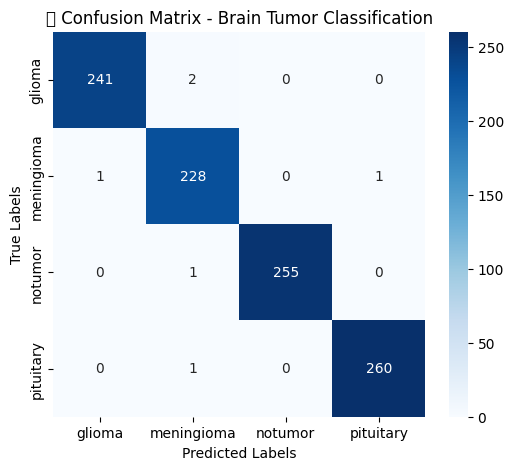

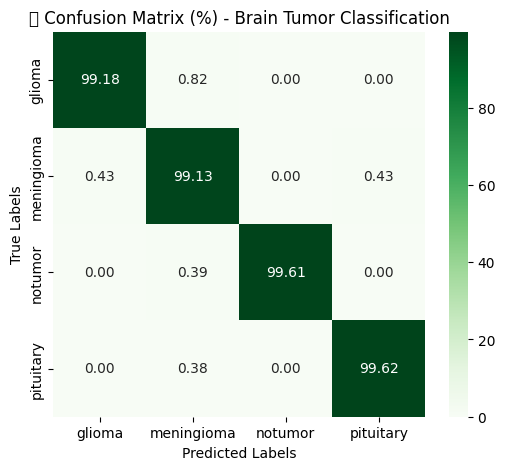

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ✅ Get true labels and predictions
y_true = test_data.classes
y_pred_probs = model.predict(test_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
class_labels = list(test_data.class_indices.keys())

# ✅ Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# ✅ Plot confusion matrix (numbers)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("🧠 Confusion Matrix - Brain Tumor Classification")
plt.show()

# ✅ Plot confusion matrix (percentages)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("📈 Confusion Matrix (%) - Brain Tumor Classification")
plt.show()


In [21]:
# ==============================
# 🔁 Fine-tuning Phase (Improving Accuracy)
# ==============================

# 1️⃣ Unfreeze the last 40 layers of the base model only
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# 2️⃣ Recompile the model with a very small learning rate
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer=Adamax(learning_rate=0.00001),   # Small learning rate to fine-tune top layers
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# 3️⃣ Use callbacks for smarter training control
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',   # Monitor validation accuracy
    patience=5,               # Stop after 5 epochs with no improvement
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # Reduce LR by half when performance plateaus
    patience=3,
    min_lr=1e-7
)

# 4️⃣ Train the model again (fine-tuning)
history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=40,                # Adjust this as needed
    callbacks=[early_stop, reduce_lr]
)

# 5️⃣ Display final results after fine-tuning
final_loss, final_acc, final_precision, final_recall = model.evaluate(test_data)
print(f"\n✅ Final Test Accuracy: {final_acc*100:.4f}%")
print(f"✅ Final Precision: {final_precision*100:.4f}%")
print(f"✅ Final Recall: {final_recall*100:.4f}%")


Epoch 1/40
145/145 ━━━━━━━━━━━━━━━━━━━━ 126s 783ms/step - accuracy: 0.9993 - loss: 0.0027 - precision_1: 0.9993 - recall_1: 0.9993 - val_accuracy: 0.9889 - val_loss: 0.0509 - val_precision_1: 0.9889 - val_recall_1: 0.9889 - learning_rate: 1.0000e-05
Epoch 2/40
145/145 ━━━━━━━━━━━━━━━━━━━━ 105s 724ms/step - accuracy: 0.9989 - loss: 0.0028 - precision_1: 0.9989 - recall_1: 0.9989 - val_accuracy: 0.9889 - val_loss: 0.0519 - val_precision_1: 0.9889 - val_recall_1: 0.9889 - learning_rate: 1.0000e-05
Epoch 3/40
145/145 ━━━━━━━━━━━━━━━━━━━━ 107s 738ms/step - accuracy: 0.9988 - loss: 0.0074 - precision_1: 0.9988 - recall_1: 0.9988 - val_accuracy: 0.9889 - val_loss: 0.0521 - val_precision_1: 0.9889 - val_recall_1: 0.9889 - learning_rate: 1.0000e-05
Epoch 4/40
145/145 ━━━━━━━━━━━━━━━━━━━━ 105s 725ms/step - accuracy: 0.9989 - loss: 0.0064 - precision_1: 0.9989 - recall_1: 0.9989 - val_accuracy: 0.9889 - val_loss: 0.0519 - val_precision_1: 0.9889 - val_recall_1: 0.9889 - learning_rate: 1.0000e-05


In [22]:
# ==============================
# 📊 Evaluate Model Performance after Fine-Tuning
# ==============================

# Evaluate on training, validation, and test data
train_loss, train_acc, train_prec, train_rec = model.evaluate(train_data, verbose=1)
val_loss, val_acc, val_prec, val_rec = model.evaluate(valid_data, verbose=1)
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_data, verbose=1)

# Print results neatly
print("\n✅ Model Performance After Fine-Tuning:")
print(f"🔹 Train Loss: {train_loss:.4f}")
print(f"🔹 Train Accuracy: {train_acc*100:.2f}%")
print("-" * 30)
print(f"🔹 Validation Loss: {val_loss:.4f}")
print(f"🔹 Validation Accuracy: {val_acc*100:.2f}%")
print("-" * 30)
print(f"🔹 Test Loss: {test_loss:.4f}")
print(f"🔹 Test Accuracy: {test_acc*100:.2f}%")


145/145 ━━━━━━━━━━━━━━━━━━━━ 104s 717ms/step - accuracy: 0.9987 - loss: 0.0038 - precision_1: 0.9987 - recall_1: 0.9987
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.9913 - loss: 0.0438 - precision_1: 0.9913 - recall_1: 0.9913
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.9924 - loss: 0.0711 - precision_1: 0.9924 - recall_1: 0.9924

✅ Model Performance After Fine-Tuning:
🔹 Train Loss: 0.0033
🔹 Train Accuracy: 99.91%
------------------------------
🔹 Validation Loss: 0.0509
🔹 Validation Accuracy: 98.89%
------------------------------
🔹 Test Loss: 0.0448
🔹 Test Accuracy: 99.39%


In [23]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Get predictions from the model on the test data
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)   # Predicted class indices
y_true = test_data.classes                   # True class indices

# 🔹 Class names (if not already included in test_data)
class_labels = list(test_data.class_indices.keys())

# 🔹 Print the report
print("\n📊 Classification Report after Fine-Tuning:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step

📊 Classification Report after Fine-Tuning:

              precision    recall  f1-score   support

      glioma       1.00      0.99      0.99       243
  meningioma       0.98      0.99      0.99       230
     notumor       1.00      1.00      1.00       256
   pituitary       1.00      1.00      1.00       261

    accuracy                           0.99       990
   macro avg       0.99      0.99      0.99       990
weighted avg       0.99      0.99      0.99       990



In [24]:
model.save("/kaggle/working/brain_tumer_remove_duplicates_model.h5")
print("✅ Model saved successfully at /kaggle/working/brain_tumer_remove_duplicates_model.h5")


✅ Model saved successfully at /kaggle/working/brain_tumer_remove_duplicates_model.h5


In [ ]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications.efficientnet import preprocess_input

# IMG_SIZE = (380, 380)  # حجم الصور المناسب لـ EfficientNetB4
# BATCH_SIZE = 32

# # 🔹 Train generator with EfficientNet preprocessing + augmentation
# train_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input,  # استخدام دالة التحضير الخاصة بـ EfficientNet
#     rotation_range=5,
#     zoom_range=0.1,
#     width_shift_range=0.05,
#     height_shift_range=0.05,
#     shear_range=0.05,
#     brightness_range=(0.8, 1.25),
#     fill_mode='nearest'
# )

# # 🔹 Validation & test generators مع نفس الـ preprocessing لكن بدون augmentation
# test_valid_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input
# )

# # Train generator
# train_data = train_datagen.flow_from_dataframe(
#     train_df,
#     x_col='path',
#     y_col='class_name',
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical'
# )

# # Validation generator
# valid_data = test_valid_datagen.flow_from_dataframe(
#     valid_df,
#     x_col='path',
#     y_col='class_name',
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     shuffle=False
# )

# # Test generator
# test_data = test_valid_datagen.flow_from_dataframe(
#     test_df,
#     x_col='path',
#     y_col='class_name',
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     shuffle=False
# )


Found 4617 validated image filenames belonging to 4 classes.
Found 990 validated image filenames belonging to 4 classes.
Found 990 validated image filenames belonging to 4 classes.


In [ ]:
# base_model = tf.keras.applications.EfficientNetB4(
#     include_top=False,
#     weights='imagenet',
#     input_shape=IMG_SIZE + (3,),
#     pooling='max'
# )

# base_model.trainable = False  # نجمّد طبقات الـ base model مبدئيًا

# model = Sequential([
#     base_model,
#     BatchNormalization(),
#     Dropout(0.3),
#     Dense(128, activation='relu'),
#     Dropout(0.25),
#     Dense(4, activation='softmax')
# ])

# model.compile(
#     optimizer=Adamax(learning_rate=0.001),
#     loss='categorical_crossentropy',
#     metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
# )

# model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       229,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,911,011 (68.33 MB)

 Trainable params: 233,604 (912.52 KB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [ ]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=7,
#     verbose=1,
#     mode='min',
#     restore_best_weights=True
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=5,
#     min_lr=1e-7,
#     verbose=1
# )


In [ ]:
# history = model.fit(
#     train_data,
#     validation_data=valid_data,
#     epochs=20,
#     callbacks=[early_stop, reduce_lr]
# )


Epoch 1/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.6738 - loss: 0.9868 - precision_3: 0.7083 - recall_3: 0.6504 - val_accuracy: 0.8495 - val_loss: 0.4273 - val_precision_3: 0.8588 - val_recall_3: 0.8414 - learning_rate: 0.0010
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.8178 - loss: 0.4950 - precision_3: 0.8331 - recall_3: 0.7992 - val_accuracy: 0.9061 - val_loss: 0.2689 - val_precision_3: 0.9172 - val_recall_3: 0.8949 - learning_rate: 0.0010
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.8557 - loss: 0.3935 - precision_3: 0.8689 - recall_3: 0.8408 - val_accuracy: 0.9131 - val_loss: 0.2444 - val_precision_3: 0.9179 - val_recall_3: 0.9040 - learning_rate: 0.0010
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.8638 - loss: 0.3493 - precision_3: 0.8790 - recall_3: 0.8534 - val_accuracy: 0.9172 - val_loss: 0.2328 - val_precision_3: 0.9289 - val_recall_3: 0.9101 - learning_rate: 0.0010
Epoch 5/20
145/145 ━━━━━━━━━

In [ ]:
# # ====== Evaluate on Train Data ======
# train_loss, train_acc, train_prec, train_rec = model.evaluate(train_data, verbose=1)
# print(f"Train Loss: {train_loss:.4f}")
# print(f"Train Accuracy: {train_acc*100:.2f}%")
# print(f"Train Precision: {train_prec*100:.2f}%")
# print(f"Train Recall: {train_rec*100:.2f}%")
# print("-" * 30)

# # ====== Evaluate on Validation Data ======
# val_loss, val_acc, val_prec, val_rec = model.evaluate(valid_data, verbose=1)
# print(f"Validation Loss: {val_loss:.4f}")
# print(f"Validation Accuracy: {val_acc*100:.2f}%")
# print(f"Validation Precision: {val_prec*100:.2f}%")
# print(f"Validation Recall: {val_rec*100:.2f}%")
# print("-" * 30)

# # ====== Evaluate on Test Data ======
# test_loss, test_acc, test_prec, test_rec = model.evaluate(test_data, verbose=1)
# print(f"Test Loss: {test_loss:.4f}")
# print(f"Test Accuracy: {test_acc*100:.2f}%")
# print(f"Test Precision: {test_prec*100:.2f}%")
# print(f"Test Recall: {test_rec*100:.2f}%")
# print("-" * 30)

145/145 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9761 - loss: 0.0685 - precision_3: 0.9773 - recall_3: 0.9725
Train Loss: 0.0667
Train Accuracy: 97.73%
Train Precision: 97.87%
Train Recall: 97.49%
------------------------------
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9540 - loss: 0.1393 - precision_3: 0.9540 - recall_3: 0.9456
Validation Loss: 0.1518
Validation Accuracy: 94.85%
Validation Precision: 94.92%
Validation Recall: 94.34%
------------------------------
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.9666 - loss: 0.0943 - precision_3: 0.9686 - recall_3: 0.9623
Test Loss: 0.1092
Test Accuracy: 95.96%
Test Precision: 96.23%
Test Recall: 95.45%
------------------------------


31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 494ms/step

Classification Report on Test Set:

              precision    recall  f1-score   support

      glioma       0.97      0.93      0.95       243
  meningioma       0.90      0.94      0.92       230
     notumor       1.00      0.98      0.99       256
   pituitary       0.97      0.98      0.98       261

    accuracy                           0.96       990
   macro avg       0.96      0.96      0.96       990
weighted avg       0.96      0.96      0.96       990



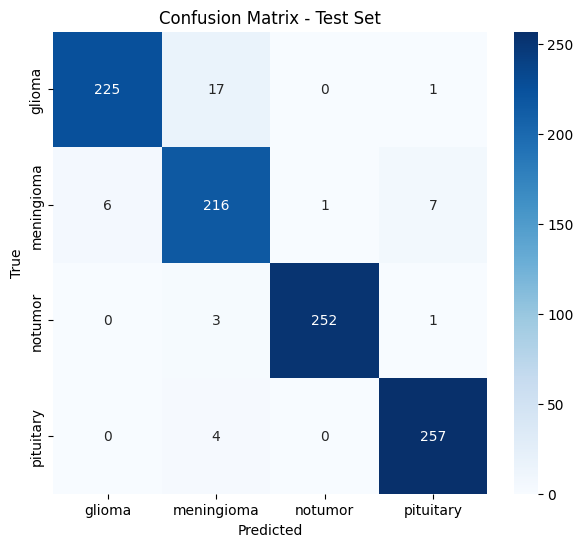

In [ ]:
# # ====== Classification Report & Confusion Matrix on Test ======

# # Predict on test set
# y_pred_probs = model.predict(test_data)
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_data.classes
# class_labels = list(test_data.class_indices.keys())

# print("\nClassification Report on Test Set:\n")
# print(classification_report(y_true, y_pred, target_names=class_labels))

# # Confusion Matrix plot
# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(7,6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=class_labels,
#             yticklabels=class_labels)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix - Test Set')
# plt.show()

In [ ]:
# for layer in base_model.layers[:-20]:
#     layer.trainable = False
# for layer in base_model.layers[-20:]:
#     layer.trainable = True

# model.compile(
#     optimizer=Adamax(learning_rate=1e-5),
#     loss='categorical_crossentropy',
#     metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
# )

# fine_tune_history = model.fit(
#     train_data,
#     validation_data=valid_data,
#     epochs=40,
#     callbacks=[early_stop, reduce_lr]
# )


Epoch 1/40


E0000 00:00:1764800655.569438     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764800655.853210     125 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 57/145 ━━━━━━━━━━━━━━━━━━━━ 1:29 1s/step - accuracy: 0.8973 - loss: 0.2468 - precision_4: 0.9061 - recall_4: 0.8920

E0000 00:00:1764800733.902445     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764800734.180756     123 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


145/145 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9016 - loss: 0.2440 - precision_4: 0.9103 - recall_4: 0.8952 - val_accuracy: 0.9424 - val_loss: 0.1654 - val_precision_4: 0.9499 - val_recall_4: 0.9394 - learning_rate: 1.0000e-05
Epoch 2/40
145/145 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9008 - loss: 0.2453 - precision_4: 0.9100 - recall_4: 0.8934 - val_accuracy: 0.9404 - val_loss: 0.1699 - val_precision_4: 0.9439 - val_recall_4: 0.9354 - learning_rate: 1.0000e-05
Epoch 3/40
145/145 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9089 - loss: 0.2252 - precision_4: 0.9162 - recall_4: 0.8998 - val_accuracy: 0.9374 - val_loss: 0.1703 - val_precision_4: 0.9438 - val_recall_4: 0.9323 - learning_rate: 1.0000e-05
Epoch 4/40
145/145 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9028 - loss: 0.2562 - precision_4: 0.9079 - recall_4: 0.8946 - val_accuracy: 0.9364 - val_loss: 0.1700 - val_precision_4: 0.9427 - val_recall_4: 0.9313 - learning_rate: 1.0000e-05
Epoch 5/40
145/145 ━━━━

31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.9556 - loss: 0.1127 - precision_4: 0.9616 - recall_4: 0.9515
Test Accuracy: 95.45%
Test Precision: 96.22%
Test Recall: 95.15%
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 460ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.96      0.93      0.94       243
  meningioma       0.90      0.93      0.91       230
     notumor       1.00      0.98      0.99       256
   pituitary       0.96      0.98      0.97       261

    accuracy                           0.95       990
   macro avg       0.95      0.95      0.95       990
weighted avg       0.96      0.95      0.95       990



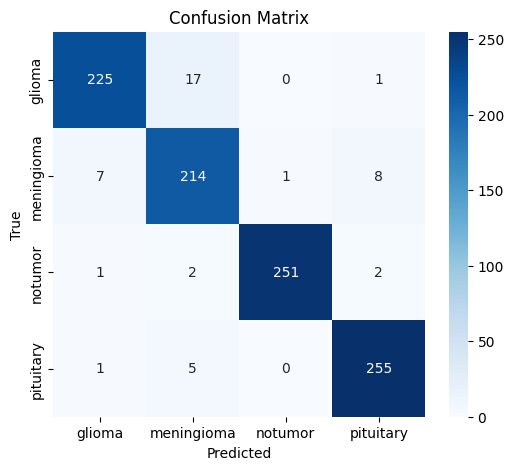

In [ ]:
# test_loss, test_acc, test_prec, test_rec = model.evaluate(test_data)
# print(f"Test Accuracy: {test_acc*100:.2f}%")
# print(f"Test Precision: {test_prec*100:.2f}%")
# print(f"Test Recall: {test_rec*100:.2f}%")

# y_pred_probs = model.predict(test_data)
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_data.classes
# class_labels = list(test_data.class_indices.keys())

# print("\nClassification Report:\n")
# print(classification_report(y_true, y_pred, target_names=class_labels))

# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=class_labels, yticklabels=class_labels)
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()


In [ ]:
# model.save('/kaggle/working/brain_tumor_efficientnetb4.h5')
# print("Model saved successfully.")
